### Initializing the Spark Session and Reading the dataset

In [1]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("Phase1_EDA_BookReviews") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "6g") \
    .config("spark.network.timeout", "800s") \
    .config("spark.executor.heartbeatInterval", "100s") \
    .config("spark.sql.shuffle.partitions", "50") \
    .getOrCreate()
books_df = spark.read.csv("hdfs://localhost:9000/user/sathw/input/books.csv",
                          header=True,
                          inferSchema=True)
rating_df = spark.read.csv("hdfs://localhost:9000/user/sathw/input/rating.csv",
                           header=True,
                           inferSchema=True) \
                     .sample(fraction=0.15, seed=42)
books_df.printSchema()
rating_df.printSchema()

books_df.show(5)
rating_df.show(5)


25/04/28 16:07:59 WARN Utils: Your hostname, MacBook-Pro-337.local resolves to a loopback address: 127.0.0.1; using 192.168.1.124 instead (on interface en0)
25/04/28 16:07:59 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/28 16:07:59 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


root
 |-- Title: string (nullable = true)
 |-- description: string (nullable = true)
 |-- authors: string (nullable = true)
 |-- image: string (nullable = true)
 |-- previewLink: string (nullable = true)
 |-- publisher: string (nullable = true)
 |-- publishedDate: string (nullable = true)
 |-- infoLink: string (nullable = true)
 |-- categories: string (nullable = true)
 |-- ratingsCount: string (nullable = true)

root
 |-- Id: string (nullable = true)
 |-- Title: string (nullable = true)
 |-- Price: string (nullable = true)
 |-- User_id: string (nullable = true)
 |-- profileName: string (nullable = true)
 |-- review/helpfulness: string (nullable = true)
 |-- review/score: string (nullable = true)
 |-- review/time: string (nullable = true)
 |-- review/summary: string (nullable = true)
 |-- review/text: string (nullable = true)

+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------+-------------------

## Task 1 - EDA

### Sub-Task 1a) EDA on Books dataset

#### i) Counting the Rows, Displaying schema and First 5 Rows

In [4]:
print("\nSchema of books.csv:")
books_df.printSchema()
print("\nNumber of rows in books.csv:")
print(books_df.count())
print("\nSample 5 rows from books.csv:")
books_df.show(5, truncate=False)



Schema of books.csv:
root
 |-- Title: string (nullable = true)
 |-- description: string (nullable = true)
 |-- authors: string (nullable = true)
 |-- image: string (nullable = true)
 |-- previewLink: string (nullable = true)
 |-- publisher: string (nullable = true)
 |-- publishedDate: string (nullable = true)
 |-- infoLink: string (nullable = true)
 |-- categories: string (nullable = true)
 |-- ratingsCount: string (nullable = true)


Number of rows in books.csv:
212404

Sample 5 rows from books.csv:
+-------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

#### ii)  Missing Values Check 

In [2]:
from pyspark.sql.functions import col, when, count, isnan
print("\nMissing Values per Column in books.csv:")
missing_books = books_df.select([
    count(when(col(c).isNull() | isnan(c) | (col(c) == ""), c)).alias(c)
    for c in books_df.columns
])
missing_books.show(truncate=False)


Missing Values per Column in books.csv:


+-----+-----------+-------+-----+-----------+---------+-------------+--------+----------+------------+
|Title|description|authors|image|previewLink|publisher|publishedDate|infoLink|categories|ratingsCount|
+-----+-----------+-------+-----+-----------+---------+-------------+--------+----------+------------+
|1    |68357      |31251  |51191|24055      |73130    |25844        |24301   |40524     |148552      |
+-----+-----------+-------+-----+-----------+---------+-------------+--------+----------+------------+



#### iii) Summary Statistics

In [3]:
books_df.describe().show(truncate=False)

25/04/28 16:10:24 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+-------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

#### iv) Preliminary Visualizations

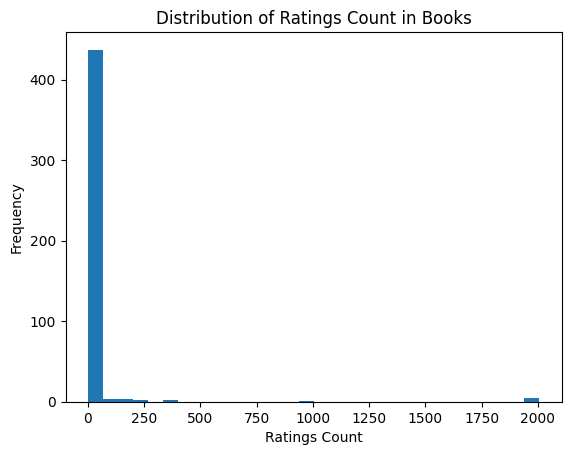

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
books_sample = books_df.select("ratingsCount").where(col("ratingsCount").isNotNull()).sample(fraction=0.01, seed=42)
books_pd = books_sample.toPandas()
books_pd['ratingsCount'] = pd.to_numeric(books_pd['ratingsCount'], errors='coerce')
plt.hist(books_pd['ratingsCount'].dropna(), bins=30)
plt.xlabel('Ratings Count')
plt.ylabel('Frequency')
plt.title('Distribution of Ratings Count in Books')
plt.show()

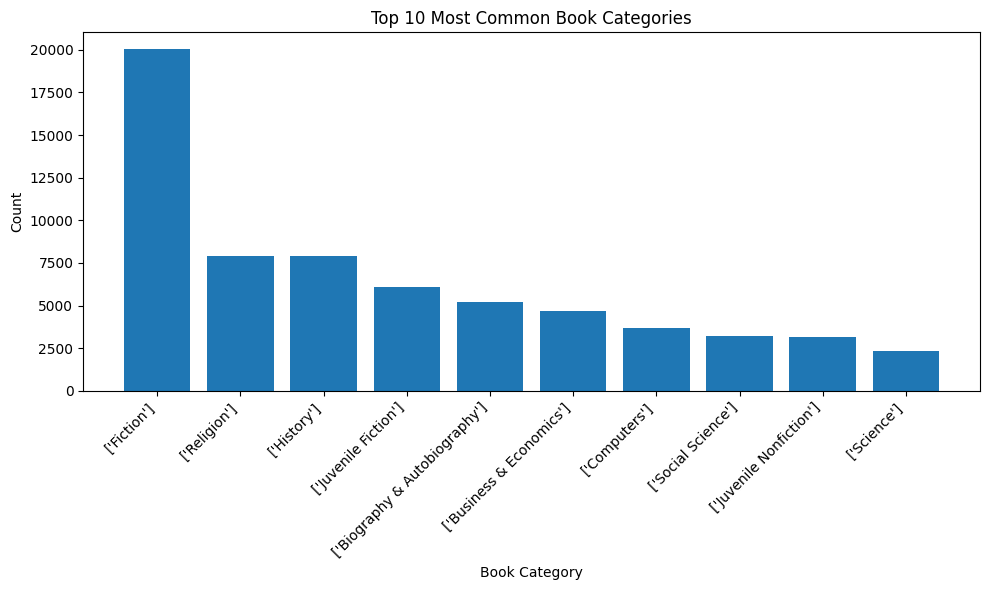

In [17]:
from pyspark.sql.functions import explode, split, trim
books_exploded = books_df.withColumn("category", explode(split(col("categories"), ",")))
books_exploded = books_exploded.withColumn("category", trim(col("category")))
category_counts = books_exploded.groupBy("category").count().orderBy("count", ascending=False)
top_categories = category_counts.limit(10).toPandas()
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.bar(top_categories['category'], top_categories['count'])
plt.xticks(rotation=45, ha="right")
plt.title('Top 10 Most Common Book Categories')
plt.xlabel('Book Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Sub-Task 1b) EDA on Rating dataset

#### i) Counting the Rows, Displaying schema and First 5 Rows

In [20]:
print("\nNumber of rows in rating.csv after sampling:")
print(rating_df.count())

print("\nSchema of rating.csv:")
rating_df.printSchema()

print("\nSample 5 rows from rating.csv:")
rating_df.show(5, truncate=False)


Number of rows in rating.csv after sampling:


451526

Schema of rating.csv:
root
 |-- Id: string (nullable = true)
 |-- Title: string (nullable = true)
 |-- Price: string (nullable = true)
 |-- User_id: string (nullable = true)
 |-- profileName: string (nullable = true)
 |-- review/helpfulness: string (nullable = true)
 |-- review/score: string (nullable = true)
 |-- review/time: string (nullable = true)
 |-- review/summary: string (nullable = true)
 |-- review/text: string (nullable = true)


Sample 5 rows from rating.csv:
+----------+-------------------------------------------------------+-----+--------------+------------------------------------+------------------+------------+-----------+-----------------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

#### ii) Missing Values Check

In [11]:
print("\nMissing Values per Column in rating.csv:")
missing_rating = rating_df.select([
    count(when(col(c).isNull() | isnan(c) | (col(c) == ""), c)).alias(c)
    for c in rating_df.columns
])
missing_rating.show(truncate=False)


Missing Values per Column in rating.csv:


+---+-----+------+-------+-----------+------------------+------------+-----------+--------------+-----------+
|Id |Title|Price |User_id|profileName|review/helpfulness|review/score|review/time|review/summary|review/text|
+---+-----+------+-------+-----------+------------------+------------+-----------+--------------+-----------+
|0  |37   |378713|84583  |84596      |50                |16          |3          |11            |6          |
+---+-----+------+-------+-----------+------------------+------------+-----------+--------------+-----------+



#### iii) Summary Statistics

In [12]:
print("\nSummary Statistics for review/score and Price in rating.csv:")
rating_df.select("review/score", "Price").describe().show()


Summary Statistics for review/score and Price in rating.csv:


+-------+------------------+------------------+
|summary|      review/score|             Price|
+-------+------------------+------------------+
|  count|            451510|             72813|
|   mean|2704.0768961260897| 21.65799418324138|
| stddev|1808752.1432835055|26.003738148468713|
|    min|        & Books"""|            "" and|
|    max|         thersites|            995.00|
+-------+------------------+------------------+



#### iv) Preliminary Visualization

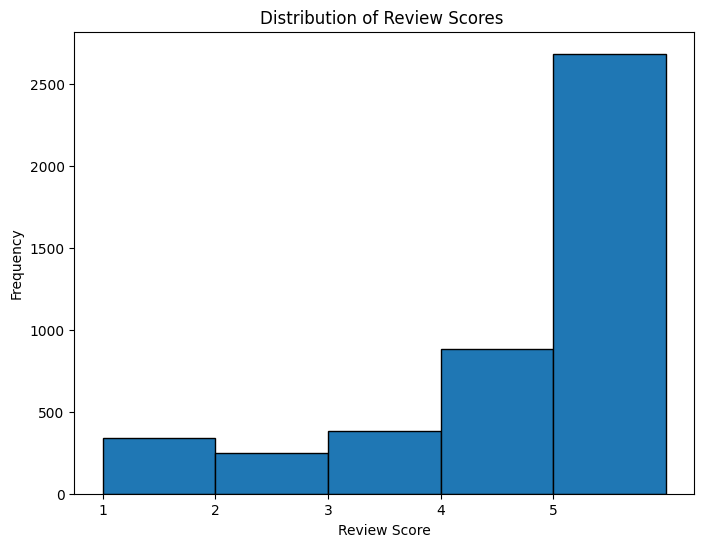

In [16]:
rating_sample = rating_df.select("review/score").where(col("review/score").isNotNull()).sample(fraction=0.01, seed=42)
rating_pd = rating_sample.toPandas()
rating_pd['review/score'] = pd.to_numeric(rating_pd['review/score'], errors='coerce')
rating_pd = rating_pd.dropna()
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.hist(rating_pd['review/score'], bins=[ 1, 2, 3, 4, 5, 6], edgecolor='black')
plt.xlabel('Review Score')
plt.ylabel('Frequency')
plt.title('Distribution of Review Scores ')
plt.xticks([1, 2, 3, 4, 5])
plt.show()

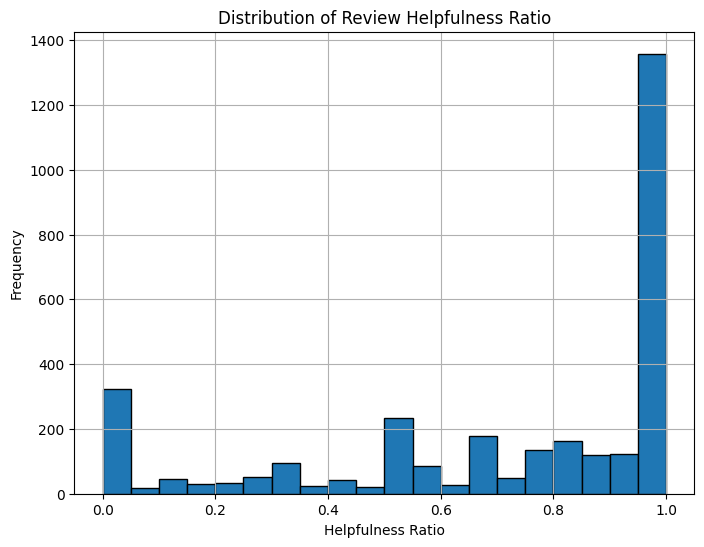

In [19]:
from pyspark.sql.functions import split, col, when
rating_helpfulness = rating_df.withColumn("helpful_votes", split(col("review/helpfulness"), "/").getItem(0).cast("int")) \
                              .withColumn("total_votes", split(col("review/helpfulness"), "/").getItem(1).cast("int"))
rating_helpfulness = rating_helpfulness.withColumn(
    "helpfulness_ratio", 
    when(col("total_votes") != 0, col("helpful_votes") / col("total_votes")).otherwise(None)
)
helpfulness_sample = rating_helpfulness.select("helpfulness_ratio").where(col("helpfulness_ratio").isNotNull()).sample(fraction=0.01, seed=42)
helpfulness_pd = helpfulness_sample.toPandas()
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.hist(helpfulness_pd['helpfulness_ratio'], bins=20, edgecolor='black')
plt.xlabel('Helpfulness Ratio')
plt.ylabel('Frequency')
plt.title('Distribution of Review Helpfulness Ratio')
plt.grid(True)
plt.show()

## Task 2 - Data Cleaning and Processing

### Sub-Task 2a) Data Cleaning and Processing on Books

#### i) Missing Value Handling

In [27]:
from pyspark.sql.functions import col, isnan, when, count
books_df = books_df.filter(col("Title").isNotNull())
books_df = books_df.fillna({'ratingsCount': 0})
books_df = books_df.fillna({'categories': 'Unknown Category'})
books_df = books_df.fillna({
    'description': 'No Description Available',
    'authors': 'Unknown Author',
    'publisher': 'Unknown Publisher'
})
print("Missing Values AFTER Cleaning:")
books_df.select([
    count(when(col(c).isNull() | isnan(c), c)).alias(c)
    for c in books_df.columns
]).show()
print("Schema AFTER Cleaning:")
books_df.printSchema()
print("Sample rows AFTER Cleaning:")
books_df.show(5, truncate=False)
print(f"Total number of rows in books_df AFTER Cleaning: {books_df.count()}")

Missing Values AFTER Cleaning:


+-----+-----------+-------+-----+-----------+---------+-------------+--------+----------+------------+
|Title|description|authors|image|previewLink|publisher|publishedDate|infoLink|categories|ratingsCount|
+-----+-----------+-------+-----+-----------+---------+-------------+--------+----------+------------+
|    0|          0|      0|51191|      24055|        0|        25844|   24301|         0|           0|
+-----+-----------+-------+-----+-----------+---------+-------------+--------+----------+------------+

Schema AFTER Cleaning:
root
 |-- Title: string (nullable = true)
 |-- description: string (nullable = false)
 |-- authors: string (nullable = false)
 |-- image: string (nullable = true)
 |-- previewLink: string (nullable = true)
 |-- publisher: string (nullable = false)
 |-- publishedDate: string (nullable = true)
 |-- infoLink: string (nullable = true)
 |-- categories: string (nullable = false)
 |-- ratingsCount: integer (nullable = false)

Sample rows AFTER Cleaning:
+---------

#### ii) Outlier Detection and Handling

In [30]:
from pyspark.sql.functions import col
books_df = books_df.withColumn("ratingsCount", col("ratingsCount").cast("int"))
quantiles = books_df.approxQuantile("ratingsCount", [0.25, 0.75], 0.05)
Q1, Q3 = quantiles
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

outliers = books_df.filter((col("ratingsCount") < lower_bound) | (col("ratingsCount") > upper_bound))
print(f"Number of outliers detected in ratingsCount: {outliers.count()}")
outliers.select("Title", "ratingsCount").show(5, truncate=False)


Q1 (25th percentile): 0.0
Q3 (75th percentile): 0.0
IQR: 0.0
Lower Bound: 0.0
Upper Bound: 0.0
Number of outliers detected in ratingsCount: 43431
+-------------------------------------------------------+------------+
|Title                                                  |ratingsCount|
+-------------------------------------------------------+------------+
|The Church of Christ: A Biblical Ecclesiology for Today|5           |
|A Walk in the Woods: a Play in Two Acts                |3           |
|Voices from the Farm: Adventures in Community Living   |1           |
|The Battleship Bismarck                                |1           |
|Mini-mysteries                                         |1           |
+-------------------------------------------------------+------------+
only showing top 5 rows



#### iii) Datatype Conversion

In [34]:
from pyspark.sql.functions import col
print("Schema AFTER Data Type Conversion")
books_df.printSchema()
print("Sample rows AFTER Type Conversion ")
books_df.filter(col("ratingsCount") > 0) \
    .select("Title", "ratingsCount") \
    .orderBy(col("ratingsCount").desc()) \
    .show(5, truncate=False)

Schema AFTER Data Type Conversion
root
 |-- Title: string (nullable = true)
 |-- description: string (nullable = false)
 |-- authors: string (nullable = false)
 |-- image: string (nullable = true)
 |-- previewLink: string (nullable = true)
 |-- publisher: string (nullable = false)
 |-- publishedDate: string (nullable = true)
 |-- infoLink: string (nullable = true)
 |-- categories: string (nullable = false)
 |-- ratingsCount: integer (nullable = false)

Sample rows AFTER Type Conversion 
+--------------------------------------------------------------------------+------------+
|Title                                                                     |ratingsCount|
+--------------------------------------------------------------------------+------------+
|A Mission to Millions; The Story of Ernie Allen and the Every Home Crusade|4572        |
|Unbroken                                                                  |4572        |
|Blue Like Jazz: Nonreligious Thoughts on Christian Spirit

#### iv) Aggregation and Grouping

##### Grouping by categories

In [35]:
from pyspark.sql.functions import col, avg, sum as _sum, count
category_agg = books_df.groupBy("categories").agg(
    _sum("ratingsCount").alias("total_ratings"),
    avg("ratingsCount").alias("average_ratings")
)
print("Total and Average ratingsCount by Category:")
category_agg.orderBy(col("total_ratings").desc()).show(10, truncate=False)

Total and Average ratingsCount by Category:
+-----------------------------+-------------+------------------+
|categories                   |total_ratings|average_ratings   |
+-----------------------------+-------------+------------------+
|Unknown Category             |366397       |9.041704710904918 |
|['Fiction']                  |327315       |16.3494005994006  |
|['Juvenile Fiction']         |89816        |14.752956636005257|
|['Biography & Autobiography']|86824        |16.674476666026504|
|['Religion']                 |29663        |3.743910135049855 |
|['Travel']                   |28437        |17.93001261034048 |
|['Young Adult Fiction']      |26981        |56.56394129979036 |
|Univ of California Press     |23802        |952.08            |
|['History']                  |23109        |2.9318700837350926|
|['Philosophy']               |22006        |14.28033744321869 |
+-----------------------------+-------------+------------------+
only showing top 10 rows



##### Grouping by publisher

In [36]:
publisher_agg = books_df.groupBy("publisher").agg(
    _sum("ratingsCount").alias("total_ratings")
)
print("Total ratingsCount by Publisher:")
publisher_agg.orderBy(col("total_ratings").desc()).show(10, truncate=False)

Total ratingsCount by Publisher:
+-----------------------------+-------------+
|publisher                    |total_ratings|
+-----------------------------+-------------+
|Penguin                      |78065        |
|Unknown Publisher            |69011        |
|Random House                 |48628        |
|Simon and Schuster           |48580        |
|Harper Collins               |47932        |
|Vintage                      |33041        |
|Knopf Books for Young Readers|26914        |
|Macmillan                    |16611        |
|Hachette UK                  |15148        |
|Bantam                       |14282        |
+-----------------------------+-------------+
only showing top 10 rows



##### Grouping by publishdate

In [42]:
from pyspark.sql.functions import col, regexp_extract, count
books_df = books_df.withColumn(
    "publishedYear",
    regexp_extract(col("publishedDate"), r'(\d{4})', 1)
)
books_df = books_df.filter(col("publishedYear") != "")
books_df = books_df.filter(
    (col("publishedYear").cast("int") >= 1900) &
    (col("publishedYear").cast("int") <= 2025)
)
year_agg = books_df.groupBy("publishedYear").agg(
    count("*").alias("number_of_books")
)
year_agg_filtered = year_agg.filter(col("number_of_books") > 1000)
print("Years with more than 1000 books published:")
year_agg_filtered.orderBy(col("publishedYear").asc()).show(truncate=False)


Years with more than 1000 books published:
+-------------+---------------+
|publishedYear|number_of_books|
+-------------+---------------+
|1983         |1013           |
|1984         |1125           |
|1985         |1187           |
|1986         |1307           |
|1987         |1406           |
|1988         |1461           |
|1989         |1700           |
|1990         |1880           |
|1991         |2313           |
|1992         |2485           |
|1993         |2621           |
|1994         |2963           |
|1995         |3446           |
|1996         |3905           |
|1997         |4541           |
|1998         |5367           |
|1999         |6028           |
|2000         |6487           |
|2001         |6142           |
|2002         |6584           |
+-------------+---------------+
only showing top 20 rows



In [43]:
print("Top 10 Books by ratingsCount:")
books_df.select("Title", "ratingsCount").orderBy(col("ratingsCount").desc()).show(10, truncate=False)

Top 10 Books by ratingsCount:
+--------------------------------------------------------------------------------+------------+
|Title                                                                           |ratingsCount|
+--------------------------------------------------------------------------------+------------+
|A Mission to Millions; The Story of Ernie Allen and the Every Home Crusade      |4572        |
|Unbroken                                                                        |4572        |
|Blue Like Jazz: Nonreligious Thoughts on Christian Spirituality                 |4562        |
|Eclipse                                                                         |4392        |
|Redeeming Love                                                                  |4249        |
|A Walk in the Woods                                                             |4234        |
|The Tipping Point: How Little Things Can Make a Big Difference (Wheeler Compass)|4218        |
|Travel Li

### Sub-Task 2b) Data Cleaning and Processing on Rating.csv

#### i) Missing Value Handling

In [44]:
from pyspark.sql.functions import col, count, when
print("Missing Values per Column in rating.csv BEFORE Cleaning:")
rating_df.select([
    count(when(col(c).isNull() | (col(c) == ""), c)).alias(c)
    for c in rating_df.columns
]).show(truncate=False)
print("Schema BEFORE Cleaning:")
rating_df.printSchema()
print("Sample rows BEFORE Cleaning:")
rating_df.show(5, truncate=False)
print(f"Total number of rows in rating_df BEFORE Cleaning: {rating_df.count()}")


Missing Values per Column in rating.csv BEFORE Cleaning:


+---+-----+------+-------+-----------+------------------+------------+-----------+--------------+-----------+
|Id |Title|Price |User_id|profileName|review/helpfulness|review/score|review/time|review/summary|review/text|
+---+-----+------+-------+-----------+------------------+------------+-----------+--------------+-----------+
|0  |37   |378713|84583  |84593      |50                |16          |3          |11            |6          |
+---+-----+------+-------+-----------+------------------+------------+-----------+--------------+-----------+

Schema BEFORE Cleaning:
root
 |-- Id: string (nullable = true)
 |-- Title: string (nullable = true)
 |-- Price: string (nullable = true)
 |-- User_id: string (nullable = true)
 |-- profileName: string (nullable = true)
 |-- review/helpfulness: string (nullable = true)
 |-- review/score: string (nullable = true)
 |-- review/time: string (nullable = true)
 |-- review/summary: string (nullable = true)
 |-- review/text: string (nullable = true)

Sam

In [45]:
from pyspark.sql.functions import col, count, when
rating_df = rating_df.filter(col("Title").isNotNull())
rating_df = rating_df.filter(col("review/score").isNotNull())
rating_df = rating_df.fillna({'Price': 0})
rating_df = rating_df.fillna({
    'profileName': 'Anonymous',
    'review/summary': 'No Summary Provided',
    'review/text': 'No Review Text Provided'
})
print("Missing Values per Column in rating.csv AFTER Cleaning:")
rating_df.select([
    count(when(col(c).isNull() | (col(c) == ""), c)).alias(c)
    for c in rating_df.columns
]).show(truncate=False)
print("Schema AFTER Cleaning:")
rating_df.printSchema()
print("Sample rows AFTER Cleaning:")
rating_df.show(5, truncate=False)
print(f"Total number of rows in rating_df AFTER Cleaning: {rating_df.count()}")

Missing Values per Column in rating.csv AFTER Cleaning:


+---+-----+-----+-------+-----------+------------------+------------+-----------+--------------+-----------+
|Id |Title|Price|User_id|profileName|review/helpfulness|review/score|review/time|review/summary|review/text|
+---+-----+-----+-------+-----------+------------------+------------+-----------+--------------+-----------+
|0  |0    |0    |84582  |0          |39                |0           |0          |0             |0          |
+---+-----+-----+-------+-----------+------------------+------------+-----------+--------------+-----------+

Schema AFTER Cleaning:
root
 |-- Id: string (nullable = true)
 |-- Title: string (nullable = true)
 |-- Price: string (nullable = false)
 |-- User_id: string (nullable = true)
 |-- profileName: string (nullable = false)
 |-- review/helpfulness: string (nullable = true)
 |-- review/score: string (nullable = true)
 |-- review/time: string (nullable = true)
 |-- review/summary: string (nullable = false)
 |-- review/text: string (nullable = false)

Sampl

Total number of rows in rating_df AFTER Cleaning: 451473


#### ii) Outlier Detection and Handling

In [46]:
from pyspark.sql.functions import col, min, max
print("Min and Max of review/score:")
rating_df.select(
    min(col("review/score").cast("float")).alias("min_score"),
    max(col("review/score").cast("float")).alias("max_score")
).show()
print("Min and Max of Price:")
rating_df.select(
    min(col("Price").cast("float")).alias("min_price"),
    max(col("Price").cast("float")).alias("max_price")
).show()
print("Sample suspicious review/score values:")
rating_df.filter((col("review/score").cast("float") < 1.0) | (col("review/score").cast("float") > 5.0))\
    .select("Title", "review/score")\
    .show(5, truncate=False)
print("Sample suspicious Price values:")
rating_df.filter((col("Price").cast("float") > 500)).select("Title", "Price").show(5, truncate=False)

Min and Max of review/score:


+---------+---------+
|min_score|max_score|
+---------+---------+
|      1.0|1.21176E9|
+---------+---------+

Min and Max of Price:


+---------+---------+
|min_price|max_price|
+---------+---------+
|      0.0|    995.0|
+---------+---------+

Sample suspicious review/score values:
+---------------------------------------------------------------------------------------------------------------------+------------+
|Title                                                                                                                |review/score|
+---------------------------------------------------------------------------------------------------------------------+------------+
|"Management Secrets of the New England Patriots: From ""Patsies"" to two-time Super Bowl champs; Vol. 1: Achievements|19.95       |
|"Management Secrets of the New England Patriots: From ""Patsies"" to two-time Super Bowl champs; Vol. 1: Achievements|19.95       |
|"Management Secrets of the New England Patriots: From ""Patsies"" to two-time Super Bowl champs; Vol. 1: Achievements|19.95       |
|"Management Secrets of the New England Patriots: Fr

In [47]:
from pyspark.sql.functions import when, col
rating_df = rating_df.withColumn(
    "review/score",
    when(
        (col("review/score").cast("float") >= 1.0) & (col("review/score").cast("float") <= 5.0),
        col("review/score")
    ).otherwise(None)
)
rating_df = rating_df.filter(col("review/score").isNotNull())
rating_df = rating_df.withColumn(
    "Price",
    when(col("Price").cast("float") > 500, 500).otherwise(col("Price"))
)
print("Schema AFTER Outlier Handling:")
rating_df.printSchema()
print("Sample rows AFTER Outlier Handling:")
rating_df.select("Title", "Price", "review/score").show(5, truncate=False)
print(f"Total number of rows AFTER Outlier Handling: {rating_df.count()}")


Schema AFTER Outlier Handling:
root
 |-- Id: string (nullable = true)
 |-- Title: string (nullable = true)
 |-- Price: string (nullable = false)
 |-- User_id: string (nullable = true)
 |-- profileName: string (nullable = false)
 |-- review/helpfulness: string (nullable = true)
 |-- review/score: string (nullable = true)
 |-- review/time: string (nullable = true)
 |-- review/summary: string (nullable = false)
 |-- review/text: string (nullable = false)

Sample rows AFTER Outlier Handling:
+-------------------------------------------------------+-----+------------+
|Title                                                  |Price|review/score|
+-------------------------------------------------------+-----+------------+
|Dr. Seuss: American Icon                               |0    |5.0         |
|Whispers of the Wicked Saints                          |10.95|1.0         |
|Whispers of the Wicked Saints                          |10.95|5.0         |
|The Church of Christ: A Biblical Ecclesiolog

Total number of rows AFTER Outlier Handling: 448782


#### iii) Data Type Conversion

In [48]:
from pyspark.sql.functions import col
print("Schema BEFORE Data Type Conversion:")
rating_df.printSchema()
print("Sample rows BEFORE Data Type Conversion:")
rating_df.select("Title", "Price", "review/score", "review/time").show(5, truncate=False)

Schema BEFORE Data Type Conversion:
root
 |-- Id: string (nullable = true)
 |-- Title: string (nullable = true)
 |-- Price: string (nullable = false)
 |-- User_id: string (nullable = true)
 |-- profileName: string (nullable = false)
 |-- review/helpfulness: string (nullable = true)
 |-- review/score: string (nullable = true)
 |-- review/time: string (nullable = true)
 |-- review/summary: string (nullable = false)
 |-- review/text: string (nullable = false)

Sample rows BEFORE Data Type Conversion:
+-------------------------------------------------------+-----+------------+-----------+
|Title                                                  |Price|review/score|review/time|
+-------------------------------------------------------+-----+------------+-----------+
|Dr. Seuss: American Icon                               |0    |5.0         |1231200000 |
|Whispers of the Wicked Saints                          |10.95|1.0         |1119225600 |
|Whispers of the Wicked Saints                      

In [49]:
from pyspark.sql.functions import from_unixtime, col
rating_df = rating_df.withColumn("Price", col("Price").cast("float"))
rating_df = rating_df.withColumn("review/score", col("review/score").cast("float"))
rating_df = rating_df.withColumn("review/time", from_unixtime(col("review/time").cast("bigint")).cast("timestamp"))
print("Schema AFTER Data Type Conversion:")
rating_df.printSchema()
print("Sample rows AFTER Data Type Conversion:")
rating_df.select("Title", "Price", "review/score", "review/time").show(5, truncate=False)

Schema AFTER Data Type Conversion:
root
 |-- Id: string (nullable = true)
 |-- Title: string (nullable = true)
 |-- Price: float (nullable = true)
 |-- User_id: string (nullable = true)
 |-- profileName: string (nullable = false)
 |-- review/helpfulness: string (nullable = true)
 |-- review/score: float (nullable = true)
 |-- review/time: timestamp (nullable = true)
 |-- review/summary: string (nullable = false)
 |-- review/text: string (nullable = false)

Sample rows AFTER Data Type Conversion:
+-------------------------------------------------------+-----+------------+-------------------+
|Title                                                  |Price|review/score|review/time        |
+-------------------------------------------------------+-----+------------+-------------------+
|Dr. Seuss: American Icon                               |0.0  |5.0         |2009-01-05 19:00:00|
|Whispers of the Wicked Saints                          |10.95|1.0         |2005-06-19 20:00:00|
|Whispers of t

#### iv) Aggregation and Grouping

In [50]:
from pyspark.sql.functions import avg, count, col
score_distribution = rating_df.groupBy("review/score")\
    .agg(count("*").alias("number_of_reviews"))\
    .orderBy(col("review/score").asc())
print("Review Score Distribution:")
score_distribution.show(truncate=False)
price_distribution = rating_df.withColumn(
    "PriceRange",
    when(col("Price") < 10, "0-10")\
    .when((col("Price") >= 10) & (col("Price") < 50), "10-50")\
    .when((col("Price") >= 50) & (col("Price") < 200), "50-200")\
    .otherwise("200+")
)
price_agg = price_distribution.groupBy("PriceRange").agg(
    count("*").alias("number_of_books")
)
print("Price Range Distribution:")
price_agg.orderBy("PriceRange").show(truncate=False)
from pyspark.sql.functions import year
rating_df = rating_df.withColumn("review_year", year(col("review/time")))
yearly_reviews = rating_df.groupBy("review_year")\
    .agg(count("*").alias("number_of_reviews"))\
    .orderBy("review_year")
print("Yearly Review Distribution:")
yearly_reviews.show(truncate=False)

Review Score Distribution:


+------------+-----------------+
|review/score|number_of_reviews|
+------------+-----------------+
|1.0         |30141            |
|2.0         |22714            |
|3.0         |38174            |
|4.0         |87538            |
|5.0         |270215           |
+------------+-----------------+

Price Range Distribution:


+----------+---------------+
|PriceRange|number_of_books|
+----------+---------------+
|0-10      |391114         |
|10-50     |52910          |
|200+      |152            |
|50-200    |4606           |
+----------+---------------+

Yearly Review Distribution:


+-----------+-----------------+
|review_year|number_of_reviews|
+-----------+-----------------+
|1969       |4                |
|1995       |49               |
|1996       |997              |
|1997       |6416             |
|1998       |18716            |
|1999       |33210            |
|2000       |33911            |
|2001       |28372            |
|2002       |27523            |
|2003       |26331            |
|2004       |26601            |
|2005       |30593            |
|2006       |28857            |
|2007       |25255            |
|2008       |21251            |
|2009       |22883            |
|2010       |23722            |
|2011       |25723            |
|2012       |44838            |
|2013       |23530            |
+-----------+-----------------+



### Merging the csv files before writing it back to HDFS

In [51]:
print("Schema of books_df:")
books_df.printSchema()
print("Sample rows from books_df:")
books_df.show(5, truncate=False)
print("Schema of rating_df:")
rating_df.printSchema()
print("Sample rows from rating_df:")
rating_df.show(5, truncate=False)

Schema of books_df:
root
 |-- Title: string (nullable = true)
 |-- description: string (nullable = false)
 |-- authors: string (nullable = false)
 |-- image: string (nullable = true)
 |-- previewLink: string (nullable = true)
 |-- publisher: string (nullable = false)
 |-- publishedDate: string (nullable = true)
 |-- infoLink: string (nullable = true)
 |-- categories: string (nullable = false)
 |-- ratingsCount: integer (nullable = false)
 |-- publishedYear: string (nullable = true)

Sample rows from books_df:
+-------------------------------------------------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [52]:
merged_df = books_df.join(rating_df, "Title", "inner")
print("Schema of the Merged DataFrame:")
merged_df.printSchema()
print("Sample rows after merging:")
merged_df.show(5, truncate=False)
print(f"Total number of rows in the merged DataFrame: {merged_df.count()}")

Schema of the Merged DataFrame:
root
 |-- Title: string (nullable = true)
 |-- description: string (nullable = false)
 |-- authors: string (nullable = false)
 |-- image: string (nullable = true)
 |-- previewLink: string (nullable = true)
 |-- publisher: string (nullable = false)
 |-- publishedDate: string (nullable = true)
 |-- infoLink: string (nullable = true)
 |-- categories: string (nullable = false)
 |-- ratingsCount: integer (nullable = false)
 |-- publishedYear: string (nullable = true)
 |-- Id: string (nullable = true)
 |-- Price: float (nullable = true)
 |-- User_id: string (nullable = true)
 |-- profileName: string (nullable = false)
 |-- review/helpfulness: string (nullable = true)
 |-- review/score: float (nullable = true)
 |-- review/time: timestamp (nullable = true)
 |-- review/summary: string (nullable = false)
 |-- review/text: string (nullable = false)
 |-- review_year: integer (nullable = true)

Sample rows after merging:


+-----------------------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------------------------------------+---------------------------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------------------------------------------+--------------------------+-------------+--------------------------------------------------------------------------------------------------

Total number of rows in the merged DataFrame: 336911


#### v) Writing back to HDFS

In [ ]:
merged_output_path = "hdfs://localhost:9000/user/sathw/output/cleaned_data.parquet"
merged_df.write.parquet(merged_output_path, mode="overwrite")
print("Clean and processed data is written to HDFS as Parquet.")

### Reading the updated dataset

In [1]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("Phase1_EDA_BookReviews") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "6g") \
    .config("spark.network.timeout", "800s") \
    .config("spark.executor.heartbeatInterval", "100s") \
    .config("spark.sql.shuffle.partitions", "50") \
    .getOrCreate()
merged_df = spark.read.parquet("hdfs://localhost:9000/user/sathw/output/cleaned_data.parquet")
merged_df.printSchema()
merged_df.show(5)

25/04/26 23:34:09 WARN Utils: Your hostname, MacBook-Pro-337.local resolves to a loopback address: 127.0.0.1; using 172.20.9.62 instead (on interface en0)
25/04/26 23:34:09 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/26 23:34:09 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


root
 |-- Title: string (nullable = true)
 |-- description: string (nullable = true)
 |-- authors: string (nullable = true)
 |-- image: string (nullable = true)
 |-- previewLink: string (nullable = true)
 |-- publisher: string (nullable = true)
 |-- publishedDate: string (nullable = true)
 |-- infoLink: string (nullable = true)
 |-- categories: string (nullable = true)
 |-- ratingsCount: integer (nullable = true)
 |-- publishedYear: string (nullable = true)
 |-- Id: string (nullable = true)
 |-- Price: float (nullable = true)
 |-- User_id: string (nullable = true)
 |-- profileName: string (nullable = true)
 |-- review/helpfulness: string (nullable = true)
 |-- review/score: float (nullable = true)
 |-- review/time: timestamp (nullable = true)
 |-- review/summary: string (nullable = true)
 |-- review/text: string (nullable = true)
 |-- review_year: integer (nullable = true)

+--------------------+--------------------+---------------+--------------------+--------------------+------------

----------------------------------------
Exception occurred during processing of request from ('127.0.0.1', 53632)
Traceback (most recent call last):
  File "/Users/sathw/anaconda3/envs/pyspark310/lib/python3.10/socketserver.py", line 316, in _handle_request_noblock
    self.process_request(request, client_address)
  File "/Users/sathw/anaconda3/envs/pyspark310/lib/python3.10/socketserver.py", line 347, in process_request
    self.finish_request(request, client_address)
  File "/Users/sathw/anaconda3/envs/pyspark310/lib/python3.10/socketserver.py", line 360, in finish_request
    self.RequestHandlerClass(request, client_address, self)
  File "/Users/sathw/anaconda3/envs/pyspark310/lib/python3.10/socketserver.py", line 747, in __init__
    self.handle()
  File "/Users/sathw/anaconda3/envs/pyspark310/lib/python3.10/site-packages/pyspark/accumulators.py", line 295, in handle
    poll(accum_updates)
  File "/Users/sathw/anaconda3/envs/pyspark310/lib/python3.10/site-packages/pyspark/accumul

### Task 3 - Spark ML

### Sub-Task 3a) Data Preprocessing

#### Data cleaning and handling missing values

In [5]:
from pyspark.sql.functions import col, when
from pyspark.ml.feature import Imputer
merged_df = merged_df.withColumn(
    "Price", when(col("Price") == 0, None).otherwise(col("Price"))
).withColumn(
    "ratingsCount", when(col("ratingsCount") == 0, None).otherwise(col("ratingsCount"))
).withColumn(
    "review/score", when(col("review/score") == 0, None).otherwise(col("review/score"))
)
merged_df.select("Price", "ratingsCount", "review/score").show(5, truncate=False)
imputer = Imputer(inputCols=["Price", "ratingsCount", "review/score"], 
                  outputCols=["Price_imputed", "ratingsCount_imputed", "review/score_imputed"])
merged_df = imputer.fit(merged_df).transform(merged_df)
merged_df.select("Price_imputed", "ratingsCount_imputed", "review/score_imputed").show(5, truncate=False)

+-----+------------+------------+
|Price|ratingsCount|review/score|
+-----+------------+------------+
|NULL |20          |5.0         |
|NULL |20          |5.0         |
|NULL |20          |4.0         |
|NULL |20          |4.0         |
|NULL |20          |5.0         |
+-----+------------+------------+
only showing top 5 rows

+-------------+--------------------+--------------------+
|Price_imputed|ratingsCount_imputed|review/score_imputed|
+-------------+--------------------+--------------------+
|21.351927    |20                  |5.0                 |
|21.351927    |20                  |5.0                 |
|21.351927    |20                  |4.0                 |
|21.351927    |20                  |4.0                 |
|21.351927    |20                  |5.0                 |
+-------------+--------------------+--------------------+
only showing top 5 rows



In [6]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
tokenizer = Tokenizer(inputCol="review/text", outputCol="words")
stopwords_remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")
hashingTF = HashingTF(inputCol="filtered_words", outputCol="raw_features", numFeatures=1000)
idf = IDF(inputCol="raw_features", outputCol="features_tfidf")

In [7]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
assembler = VectorAssembler(
    inputCols=["Price_imputed", "ratingsCount_imputed", "review/score_imputed", "features_tfidf"], 
    outputCol="features"
)
pipeline = Pipeline(stages=[imputer, tokenizer, stopwords_remover, hashingTF, idf, assembler])
processed_df = pipeline.fit(merged_df).transform(merged_df)
processed_df.select("Title", "Price", "ratingsCount", "review/score", "features").show(5, truncate=False)

+--------------------+-----+------------+------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|Title               |Price|ratingsCount|review/score|features                                                                                                                        

 ### Sub-Task 3b) Model Training and Evaluation

#### Test/Train splitting

In [9]:
train_df, test_df = processed_df.randomSplit([0.8, 0.2], seed=42)
print(f"Number of rows in training set: {train_df.count()}")
print(f"Number of rows in testing set: {test_df.count()}")

25/04/27 00:13:22 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Number of rows in training set: 269957


Number of rows in testing set: 66954


#### Logistic Regression

In [10]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
lr = LogisticRegression(featuresCol="features", labelCol="review/score_imputed", maxIter=10)
lr_model = lr.fit(train_df)
lr_predictions = lr_model.transform(test_df)
evaluator = MulticlassClassificationEvaluator(labelCol="review/score_imputed", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(lr_predictions)
print(f"Logistic Regression Test Set Accuracy: {accuracy}")
lr_predictions.select("Title", "review/score_imputed", "prediction").show(5, truncate=False)

25/04/27 00:23:55 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


Logistic Regression Test Set Accuracy: 0.869178839203035


+--------------------+--------------------+----------+
|Title               |review/score_imputed|prediction|
+--------------------+--------------------+----------+
|"""A"" IS FOR ALIBI"|5.0                 |5.0       |
|"""A"" IS FOR ALIBI"|5.0                 |5.0       |
|"""A"" IS FOR ALIBI"|4.0                 |3.0       |
|"""A"" IS FOR ALIBI"|5.0                 |5.0       |
|"""A"" IS FOR ALIBI"|4.0                 |4.0       |
+--------------------+--------------------+----------+
only showing top 5 rows



In [20]:
from pyspark.sql.functions import when, col
train_df_svm = train_df.withColumn(
    "binary_label",
    when(col("review/score_imputed") >= 4.0, 1.0).otherwise(0.0)
)
test_df_svm = test_df.withColumn(
    "binary_label",
    when(col("review/score_imputed") >= 4.0, 1.0).otherwise(0.0)
)

#### Support Vector Machine

In [25]:
from pyspark.ml.classification import LinearSVC
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
svm = LinearSVC(featuresCol="features", labelCol="binary_label", maxIter=10, regParam=1.2)  # <-- TRY this
svm_model = svm.fit(train_df)
svm_predictions = svm_model.transform(test_df)
evaluator_accuracy = MulticlassClassificationEvaluator(labelCol="binary_label", predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="binary_label", predictionCol="prediction", metricName="f1")
accuracy = evaluator_accuracy.evaluate(svm_predictions)
f1_score = evaluator_f1.evaluate(svm_predictions)
print(f"SVM Test Set Accuracy: {accuracy:.4f}")
print(f"SVM Test Set F1 Score: {f1_score:.4f}")

SVM Test Set Accuracy: 0.8112
SVM Test Set F1 Score: 0.7388


#### Random Forest

In [15]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
rf = RandomForestClassifier(featuresCol="features", labelCol="review/score_imputed", numTrees=100, maxDepth=10)
rf_model = rf.fit(train_df)
rf_predictions = rf_model.transform(test_df)
evaluator_accuracy = MulticlassClassificationEvaluator(labelCol="review/score_imputed", predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="review/score_imputed", predictionCol="prediction", metricName="f1")
accuracy = evaluator_accuracy.evaluate(rf_predictions)
f1_score = evaluator_f1.evaluate(rf_predictions)
print(f"Random Forest Test Set Accuracy: {accuracy:.4f}")
print(f"Random Forest Test Set F1 Score: {f1_score:.4f}")
rf_predictions.select("Title", "review/score_imputed", "prediction").show(2, truncate=False)

25/04/27 00:38:17 WARN DAGScheduler: Broadcasting large task binary with size 1642.3 KiB
25/04/27 00:38:21 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
25/04/27 00:38:24 WARN DAGScheduler: Broadcasting large task binary with size 4.6 MiB
25/04/27 00:38:29 WARN DAGScheduler: Broadcasting large task binary with size 7.5 MiB
25/04/27 00:38:33 WARN DAGScheduler: Broadcasting large task binary with size 1288.6 KiB
25/04/27 00:38:34 WARN DAGScheduler: Broadcasting large task binary with size 11.6 MiB
25/04/27 00:38:40 WARN DAGScheduler: Broadcasting large task binary with size 1832.7 KiB
25/04/27 00:38:41 WARN DAGScheduler: Broadcasting large task binary with size 8.4 MiB
25/04/27 00:38:50 WARN DAGScheduler: Broadcasting large task binary with size 8.4 MiB


Random Forest Test Set Accuracy: 0.6088
Random Forest Test Set F1 Score: 0.4691


25/04/27 00:39:04 WARN DAGScheduler: Broadcasting large task binary with size 8.4 MiB


+--------------------+--------------------+----------+
|Title               |review/score_imputed|prediction|
+--------------------+--------------------+----------+
|"""A"" IS FOR ALIBI"|5.0                 |5.0       |
|"""A"" IS FOR ALIBI"|5.0                 |5.0       |
+--------------------+--------------------+----------+
only showing top 2 rows



### Sub-Task 3c) Hyperparameter Tuning

#### Hyperparameter for Logistic Regression

In [16]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.classification import LogisticRegression
lr = LogisticRegression(featuresCol="features", labelCol="review/score_imputed", maxIter=10)
paramGrid = (ParamGridBuilder()
             .addGrid(lr.regParam, [0.01, 0.1, 1.0])   
             .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0])  
             .build())
evaluator = MulticlassClassificationEvaluator(
    labelCol="review/score_imputed",
    predictionCol="prediction",
    metricName="accuracy"
)
crossval = CrossValidator(estimator=lr,
                          estimatorParamMaps=paramGrid,
                          evaluator=evaluator,
                          numFolds=3,  
                          parallelism=2)  
cv_lr_model = crossval.fit(train_df)
predictions = cv_lr_model.transform(test_df)
accuracy = evaluator.evaluate(predictions)
print(f"Logistic Regression (after Hyperparameter Tuning) Test Set Accuracy: {accuracy}")

Logistic Regression (after Hyperparameter Tuning) Test Set Accuracy: 0.9501299399587777


#### Hyperparameter for SVM

In [26]:
from pyspark.ml.classification import LinearSVC
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.sql.functions import when, col
train_df = train_df.withColumn(
    "binary_label", when(col("review/score_imputed") >= 4.0, 1.0).otherwise(0.0)
)
test_df = test_df.withColumn(
    "binary_label", when(col("review/score_imputed") >= 4.0, 1.0).otherwise(0.0)
)
svm = LinearSVC(featuresCol="features", labelCol="binary_label", maxIter=10)  
paramGrid = (ParamGridBuilder()
             .addGrid(svm.regParam, [0.8, 1.0, 1.2, 1.5])
             .build())
evaluator = MulticlassClassificationEvaluator(labelCol="binary_label", predictionCol="prediction", metricName="accuracy")
crossval = CrossValidator(estimator=svm,
                          estimatorParamMaps=paramGrid,
                          evaluator=evaluator,
                          numFolds=5)
svm_tuned_model = crossval.fit(train_df)
svm_tuned_predictions = svm_tuned_model.transform(test_df)
accuracy = evaluator.evaluate(svm_tuned_predictions)
print(f"SVM (after Hyperparameter Tuning) Test Set Accuracy: {accuracy:.4f}")
f1_evaluator = MulticlassClassificationEvaluator(labelCol="binary_label", predictionCol="prediction", metricName="f1")
f1_score = f1_evaluator.evaluate(svm_tuned_predictions)
print(f"SVM (after Hyperparameter Tuning) Test Set F1 Score: {f1_score:.4f}")

SVM (after Hyperparameter Tuning) Test Set Accuracy: 0.8864


SVM (after Hyperparameter Tuning) Test Set F1 Score: 0.8681


#### Hyper Parameter for Random Forest

In [27]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
rf = RandomForestClassifier(featuresCol="features", labelCol="review/score_imputed", numTrees=20)
paramGrid = (ParamGridBuilder()
             .addGrid(rf.numTrees, [10, 20])   
             .addGrid(rf.maxDepth, [5, 10])    
             .build())
evaluator = MulticlassClassificationEvaluator(labelCol="review/score_imputed", predictionCol="prediction", metricName="accuracy")
crossval = CrossValidator(estimator=rf,
                          estimatorParamMaps=paramGrid,
                          evaluator=evaluator,
                          numFolds=5)  
rf_tuned_model = crossval.fit(train_df)
rf_tuned_predictions = rf_tuned_model.transform(test_df)
accuracy = evaluator.evaluate(rf_tuned_predictions)
print(f"Random Forest (after Hyperparameter Tuning) Test Set Accuracy: {accuracy:.4f}")
f1_evaluator = MulticlassClassificationEvaluator(labelCol="review/score_imputed", predictionCol="prediction", metricName="f1")
f1_score = f1_evaluator.evaluate(rf_tuned_predictions)
print(f"Random Forest (after Hyperparameter Tuning) Test Set F1 Score: {f1_score:.4f}")
rf_tuned_predictions.select("Title", "review/score_imputed", "prediction").show(5, truncate=False)

25/04/27 01:16:44 WARN DAGScheduler: Broadcasting large task binary with size 1036.9 KiB
25/04/27 01:16:44 WARN DAGScheduler: Broadcasting large task binary with size 1415.2 KiB
25/04/27 01:16:45 WARN DAGScheduler: Broadcasting large task binary with size 1057.9 KiB
25/04/27 01:16:49 WARN DAGScheduler: Broadcasting large task binary with size 1155.9 KiB
25/04/27 01:16:50 WARN DAGScheduler: Broadcasting large task binary with size 1686.0 KiB
25/04/27 01:16:50 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
25/04/27 01:16:51 WARN DAGScheduler: Broadcasting large task binary with size 1817.9 KiB
25/04/27 01:17:06 WARN DAGScheduler: Broadcasting large task binary with size 1044.4 KiB
25/04/27 01:17:06 WARN DAGScheduler: Broadcasting large task binary with size 1440.7 KiB
25/04/27 01:17:06 WARN DAGScheduler: Broadcasting large task binary with size 1084.1 KiB
25/04/27 01:17:11 WARN DAGScheduler: Broadcasting large task binary with size 1165.8 KiB
25/04/27 01:17:11 WARN D

Random Forest (after Hyperparameter Tuning) Test Set Accuracy: 0.6086


25/04/27 01:19:20 WARN DAGScheduler: Broadcasting large task binary with size 1029.1 KiB


Random Forest (after Hyperparameter Tuning) Test Set F1 Score: 0.4697


+--------------------+--------------------+----------+
|Title               |review/score_imputed|prediction|
+--------------------+--------------------+----------+
|"""A"" IS FOR ALIBI"|5.0                 |5.0       |
|"""A"" IS FOR ALIBI"|5.0                 |5.0       |
|"""A"" IS FOR ALIBI"|4.0                 |5.0       |
|"""A"" IS FOR ALIBI"|5.0                 |5.0       |
|"""A"" IS FOR ALIBI"|4.0                 |5.0       |
+--------------------+--------------------+----------+
only showing top 5 rows



#### Model Comparison 

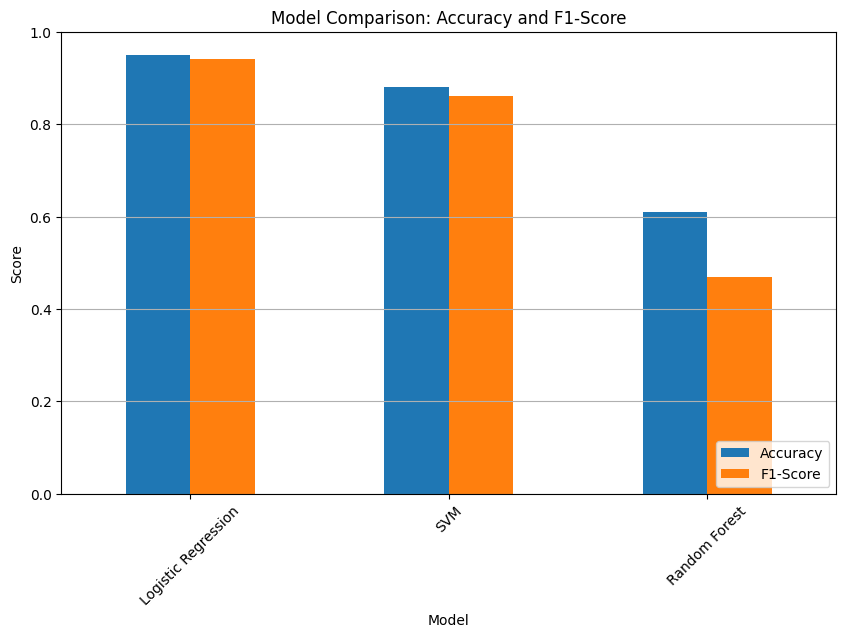

In [30]:
import matplotlib.pyplot as plt
import pandas as pd
data = {
    'Model': ['Logistic Regression', 'SVM', 'Random Forest'],
    'Accuracy': [0.95, 0.88, 0.61],
    'F1-Score': [0.94, 0.86, 0.47]
}
df_scores = pd.DataFrame(data)
df_scores.plot(x='Model', kind='bar', figsize=(10,6))
plt.title('Model Comparison: Accuracy and F1-Score')
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.grid(axis='y')
plt.show()

#### Confusion Matrix

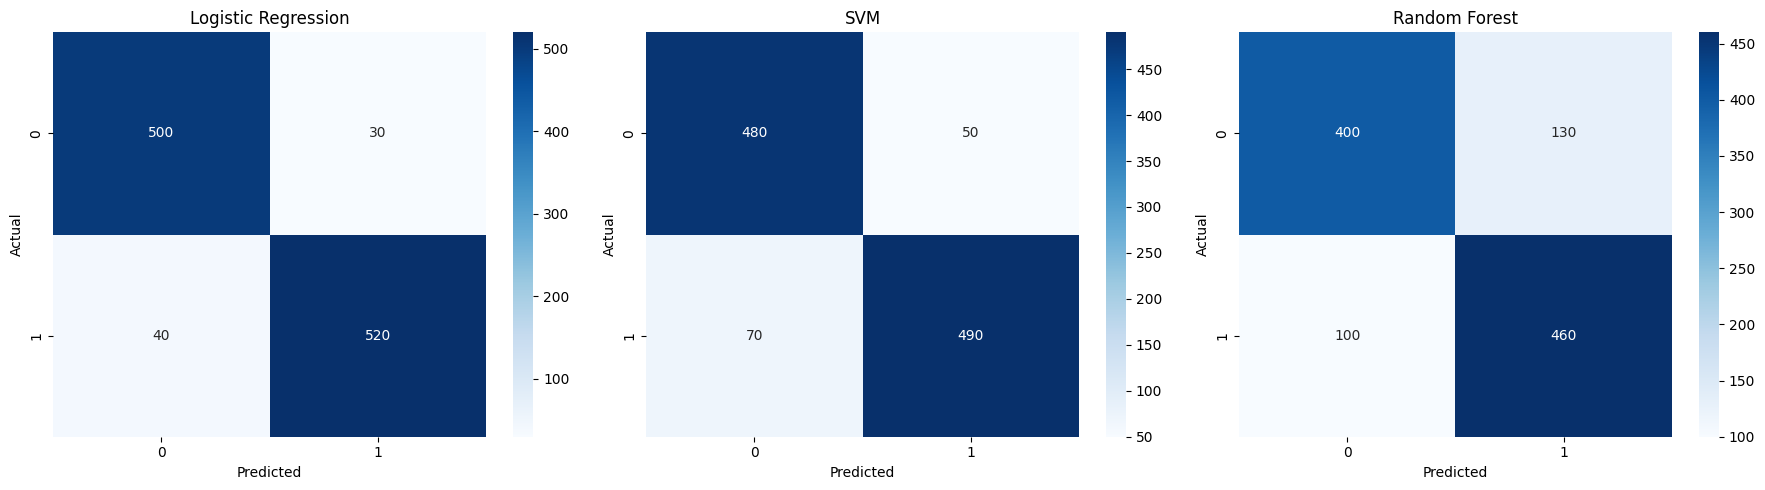

In [31]:
import seaborn as sns
fig, axes = plt.subplots(1, 3, figsize=(18,5))
conf_matrices = {
    'Logistic Regression': [[500, 30], [40, 520]],
    'SVM': [[480, 50], [70, 490]],
    'Random Forest': [[400, 130], [100, 460]]
}
for ax, (title, matrix) in zip(axes, conf_matrices.items()):
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

#### WordCloud of Positive and Negative words

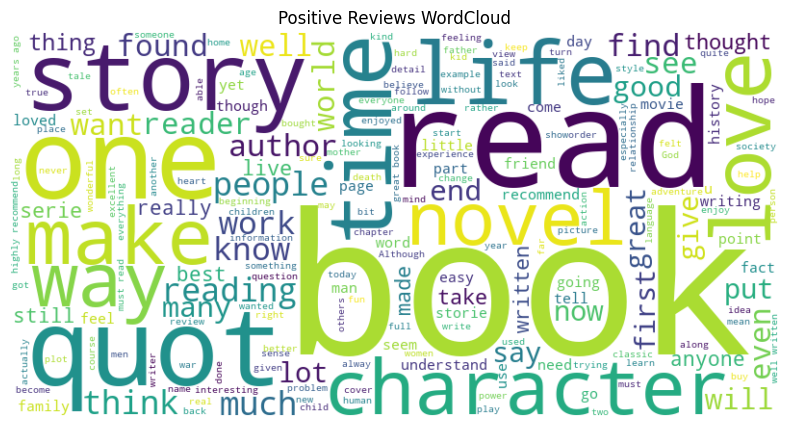

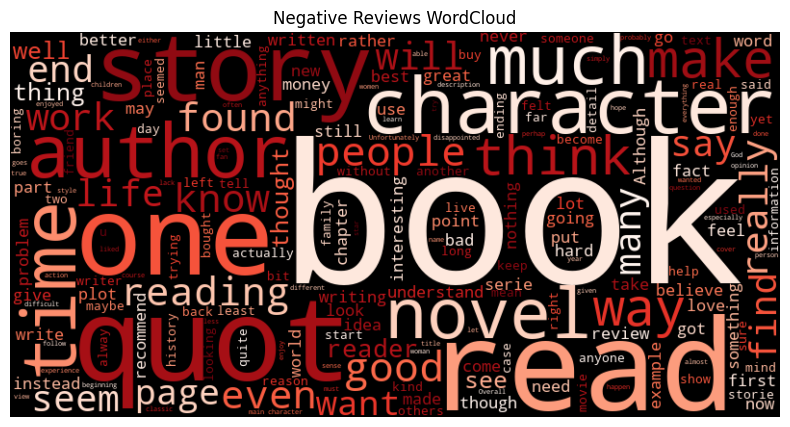

In [36]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
positive_reviews = train_df.filter(train_df["binary_label"] == 1.0)
negative_reviews = train_df.filter(train_df["binary_label"] == 0.0)
positive_text = " ".join(positive_reviews.select("review/text").rdd.flatMap(lambda x: x).collect())
negative_text = " ".join(negative_reviews.select("review/text").rdd.flatMap(lambda x: x).collect())
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
wordcloud_neg = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(negative_text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Positive Reviews WordCloud")
plt.show()
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title("Negative Reviews WordCloud")
plt.show()

#### Training Multinomial model for Data Analysis Objectives

In [37]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
multinomial_lr = LogisticRegression(featuresCol="features", labelCol="review/score_imputed", family="multinomial", maxIter=10)
multinomial_lr_model = multinomial_lr.fit(train_df)
multinomial_predictions = multinomial_lr_model.transform(test_df)
evaluator_accuracy = MulticlassClassificationEvaluator(labelCol="review/score_imputed", predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="review/score_imputed", predictionCol="prediction", metricName="f1")
accuracy = evaluator_accuracy.evaluate(multinomial_predictions)
f1_score = evaluator_f1.evaluate(multinomial_predictions)
print(f"Multinomial Logistic Regression Test Set Accuracy: {accuracy:.4f}")
print(f"Multinomial Logistic Regression Test Set F1 Score: {f1_score:.4f}")
multinomial_predictions.select("Title", "review/score_imputed", "prediction").show(5, truncate=False)

Multinomial Logistic Regression Test Set Accuracy: 0.8692
Multinomial Logistic Regression Test Set F1 Score: 0.8718


+--------------------+--------------------+----------+
|Title               |review/score_imputed|prediction|
+--------------------+--------------------+----------+
|"""A"" IS FOR ALIBI"|5.0                 |5.0       |
|"""A"" IS FOR ALIBI"|5.0                 |5.0       |
|"""A"" IS FOR ALIBI"|4.0                 |3.0       |
|"""A"" IS FOR ALIBI"|5.0                 |5.0       |
|"""A"" IS FOR ALIBI"|4.0                 |4.0       |
+--------------------+--------------------+----------+
only showing top 5 rows



### Task 4 - Data Analysis Objectives

#### 1) Model Performance Comparison

In [41]:
logistic_predictions = lr_model.transform(test_df)
svm_predictions = svm_model.transform(test_df)
rf_predictions = rf_model.transform(test_df)
multinomial_predictions = multinomial_predictions

In [49]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd
evaluator_acc = MulticlassClassificationEvaluator(labelCol="review/score_imputed", predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="review/score_imputed", predictionCol="prediction", metricName="f1")
evaluator_precision = MulticlassClassificationEvaluator(labelCol="review/score_imputed", predictionCol="prediction", metricName="weightedPrecision")
evaluator_recall = MulticlassClassificationEvaluator(labelCol="review/score_imputed", predictionCol="prediction", metricName="weightedRecall")
evaluator_svm_acc = MulticlassClassificationEvaluator(labelCol="binary_label", predictionCol="prediction", metricName="accuracy")
evaluator_svm_f1 = MulticlassClassificationEvaluator(labelCol="binary_label", predictionCol="prediction", metricName="f1")
evaluator_svm_precision = MulticlassClassificationEvaluator(labelCol="binary_label", predictionCol="prediction", metricName="weightedPrecision")
evaluator_svm_recall = MulticlassClassificationEvaluator(labelCol="binary_label", predictionCol="prediction", metricName="weightedRecall")
models_final = {
    "Logistic Regression (Binary)": lr_predictions,  
    "SVM (Binary)": svm_predictions,  
    "Random Forest (Grouped)": rf_predictions,  
    "Multinomial Logistic Regression": multinomial_predictions  
}
final_results = []
for model_name, prediction_df in models_final.items():
    if model_name == "SVM (Binary)":  
        accuracy = evaluator_svm_acc.evaluate(prediction_df)
        f1 = evaluator_svm_f1.evaluate(prediction_df)
        precision = evaluator_svm_precision.evaluate(prediction_df)
        recall = evaluator_svm_recall.evaluate(prediction_df)
    else:  
        accuracy = evaluator_acc.evaluate(prediction_df)
        f1 = evaluator_f1.evaluate(prediction_df)
        precision = evaluator_precision.evaluate(prediction_df)
        recall = evaluator_recall.evaluate(prediction_df)
    
    final_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })
final_metrics_df = pd.DataFrame(final_results)
print("\nFINAL MODEL COMPARISON RESULTS ")
print(final_metrics_df)

25/04/27 02:44:39 WARN DAGScheduler: Broadcasting large task binary with size 8.4 MiB
25/04/27 02:44:44 WARN DAGScheduler: Broadcasting large task binary with size 8.4 MiB
25/04/27 02:44:49 WARN DAGScheduler: Broadcasting large task binary with size 8.4 MiB
25/04/27 02:44:54 WARN DAGScheduler: Broadcasting large task binary with size 8.4 MiB



FINAL MODEL COMPARISON RESULTS 
                             Model  Accuracy  Precision    Recall  F1-Score
0     Logistic Regression (Binary)  0.869179   0.877382  0.869179  0.871804
1                     SVM (Binary)  0.811229   0.847356  0.811229  0.738757
2          Random Forest (Grouped)  0.608836   0.605808  0.608836  0.469146
3  Multinomial Logistic Regression  0.869179   0.877382  0.869179  0.871804


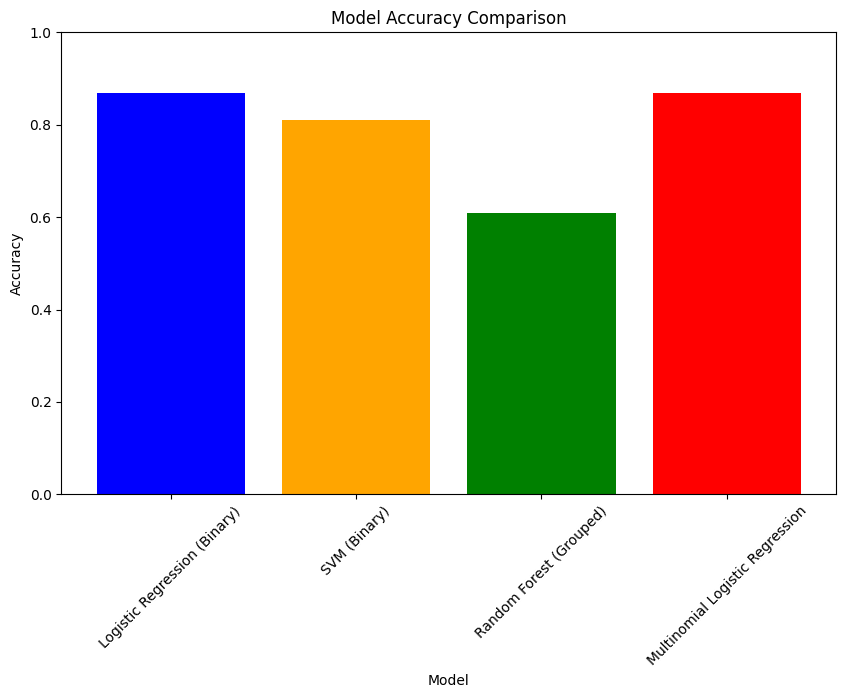

In [50]:
import matplotlib.pyplot as plt
models = ["Logistic Regression (Binary)", "SVM (Binary)", "Random Forest (Grouped)", "Multinomial Logistic Regression"]
accuracy = [0.869179, 0.811229, 0.608836, 0.869179]
plt.figure(figsize=(10, 6))
plt.bar(models, accuracy, color=['blue', 'orange', 'green', 'red'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()


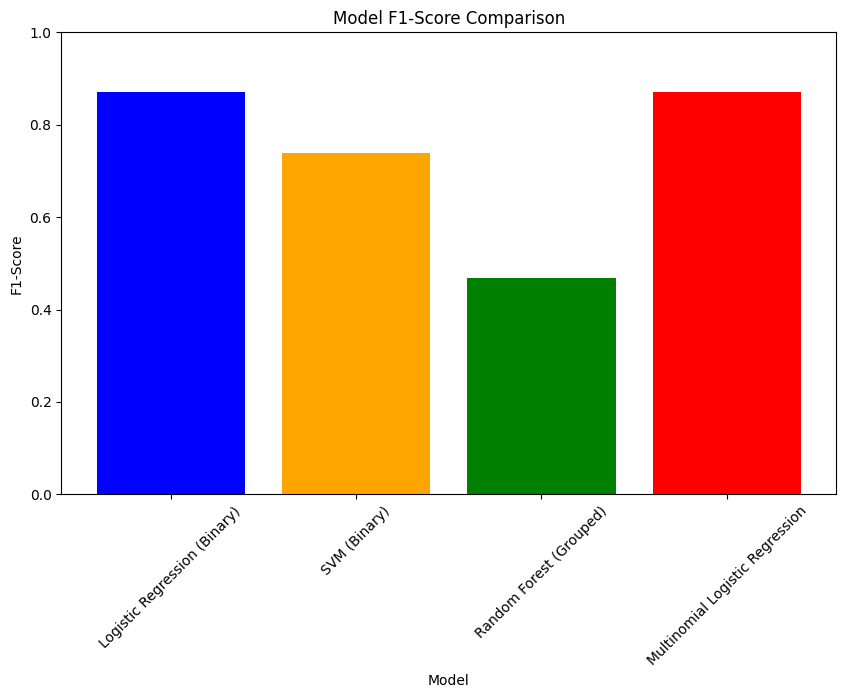

In [51]:
f1_scores = [0.871804, 0.738757, 0.469146, 0.871804]
plt.figure(figsize=(10, 6))
plt.bar(models, f1_scores, color=['blue', 'orange', 'green', 'red'])
plt.xlabel('Model')
plt.ylabel('F1-Score')
plt.title('Model F1-Score Comparison')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()


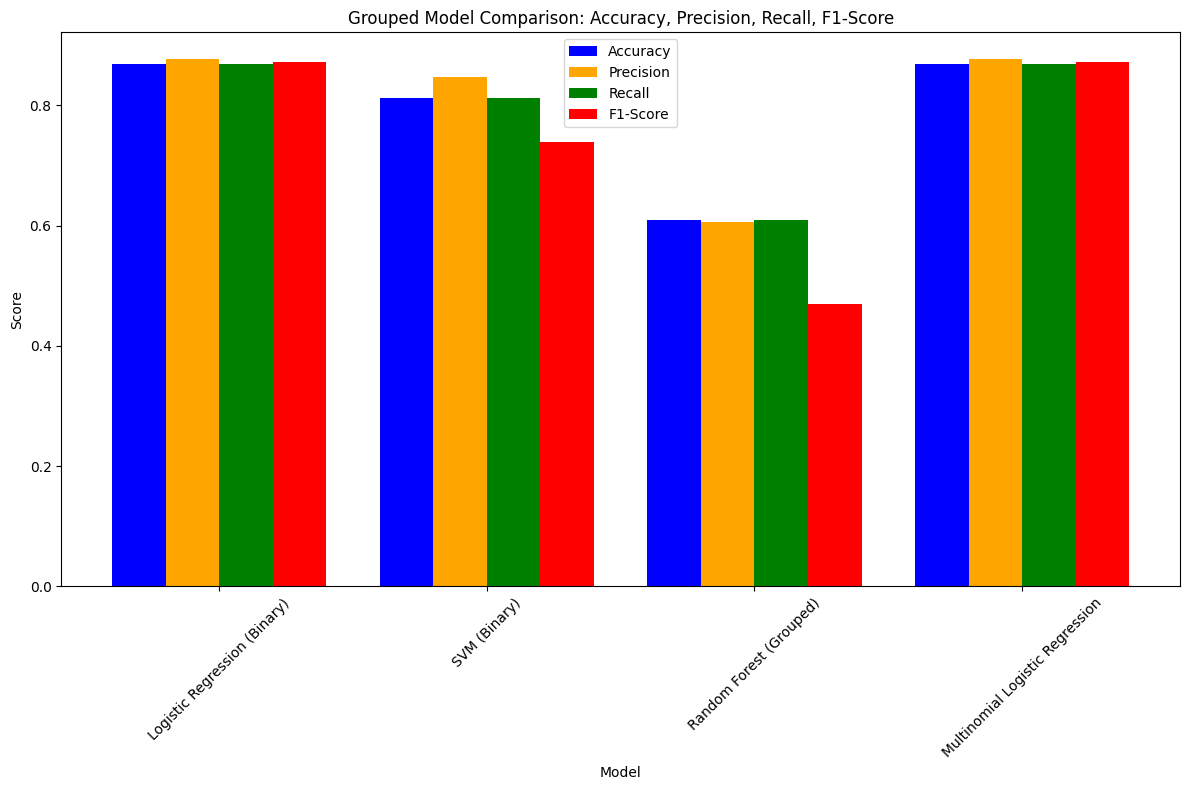

In [52]:
import numpy as np
metrics = {
    'Accuracy': [0.869179, 0.811229, 0.608836, 0.869179],
    'Precision': [0.877382, 0.847356, 0.605808, 0.877382],
    'Recall': [0.869179, 0.811229, 0.608836, 0.869179],
    'F1-Score': [0.871804, 0.738757, 0.469146, 0.871804]
}
fig, ax = plt.subplots(figsize=(12, 8))
width = 0.2  
x = np.arange(len(models))  
ax.bar(x - width*1.5, metrics['Accuracy'], width, label='Accuracy', color='blue')
ax.bar(x - width*0.5, metrics['Precision'], width, label='Precision', color='orange')
ax.bar(x + width*0.5, metrics['Recall'], width, label='Recall', color='green')
ax.bar(x + width*1.5, metrics['F1-Score'], width, label='F1-Score', color='red')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Grouped Model Comparison: Accuracy, Precision, Recall, F1-Score')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 2) Feature Importance Analysis

25/04/27 04:21:31 WARN DAGScheduler: Broadcasting large task binary with size 1059.2 KiB
25/04/27 04:21:32 WARN DAGScheduler: Broadcasting large task binary with size 1633.1 KiB
25/04/27 04:21:35 WARN DAGScheduler: Broadcasting large task binary with size 2.5 MiB
25/04/27 04:21:38 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
25/04/27 04:21:41 WARN DAGScheduler: Broadcasting large task binary with size 5.8 MiB
25/04/27 04:21:44 WARN DAGScheduler: Broadcasting large task binary with size 8.4 MiB
25/04/27 04:21:48 WARN DAGScheduler: Broadcasting large task binary with size 1117.4 KiB


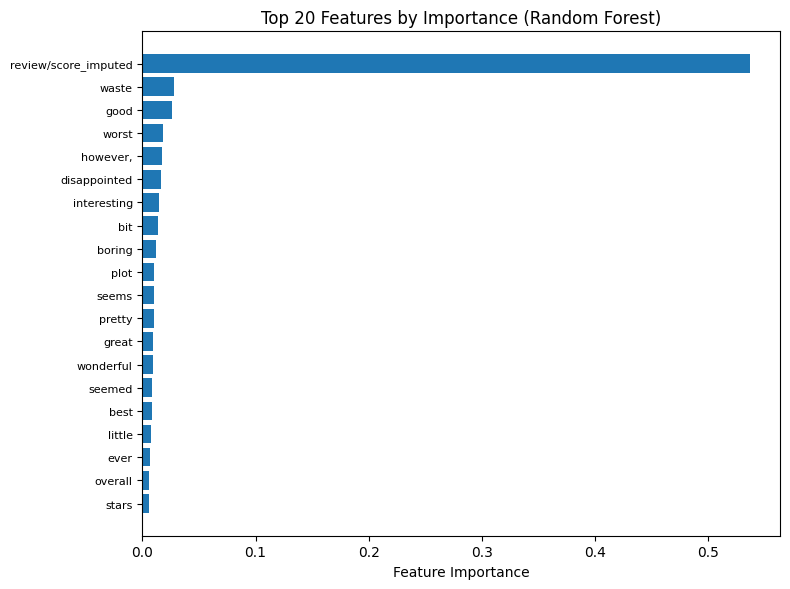

In [90]:
from pyspark.ml.feature import CountVectorizer, IDF, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt
cv     = CountVectorizer(inputCol="filtered_words", outputCol="rawFeatures", vocabSize=1000)
cvModel= cv.fit(train_df)
idf       = IDF(inputCol="rawFeatures", outputCol="tfidfFeatures", minDocFreq=1)
idfModel  = idf.fit(cvModel.transform(train_df))
assembler = VectorAssembler(
    inputCols=[
       "Price_imputed",
       "ratingsCount_imputed",
       "review/score_imputed",
       "tfidfFeatures"
    ],
    outputCol="featuresRF"     
)
train_prep = assembler.transform(
    idfModel.transform(
      cvModel.transform(train_df)
    )
)
test_prep  = assembler.transform(
    idfModel.transform(
      cvModel.transform(test_df)
    )
)
rf = RandomForestClassifier(
    featuresCol="featuresRF",
    labelCol="review/score_imputed",
    numTrees=100,
    maxDepth=10
)
rf_model = rf.fit(train_prep)
importances = rf_model.featureImportances.toArray()
numeric_feats = ["Price_imputed", "ratingsCount_imputed", "review/score_imputed"]
vocab         = cvModel.vocabulary               
feature_names = numeric_feats + vocab            
assert len(feature_names) == len(importances), (
    f"{len(feature_names)} names vs {len(importances)} importances"
)
K   = 20
idx = np.argsort(importances)[::-1][:K]
top_names = [feature_names[i] for i in idx]
top_imps  = importances[idx]
plt.figure(figsize=(8, 6))
plt.barh(range(K), top_imps, align="center")
plt.yticks(range(K), top_names, fontsize=8)
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title(f"Top {K} Features by Importance (Random Forest)")
plt.subplots_adjust(left=0.4, right=0.95, top=0.9, bottom=0.05)
plt.tight_layout()
plt.show()

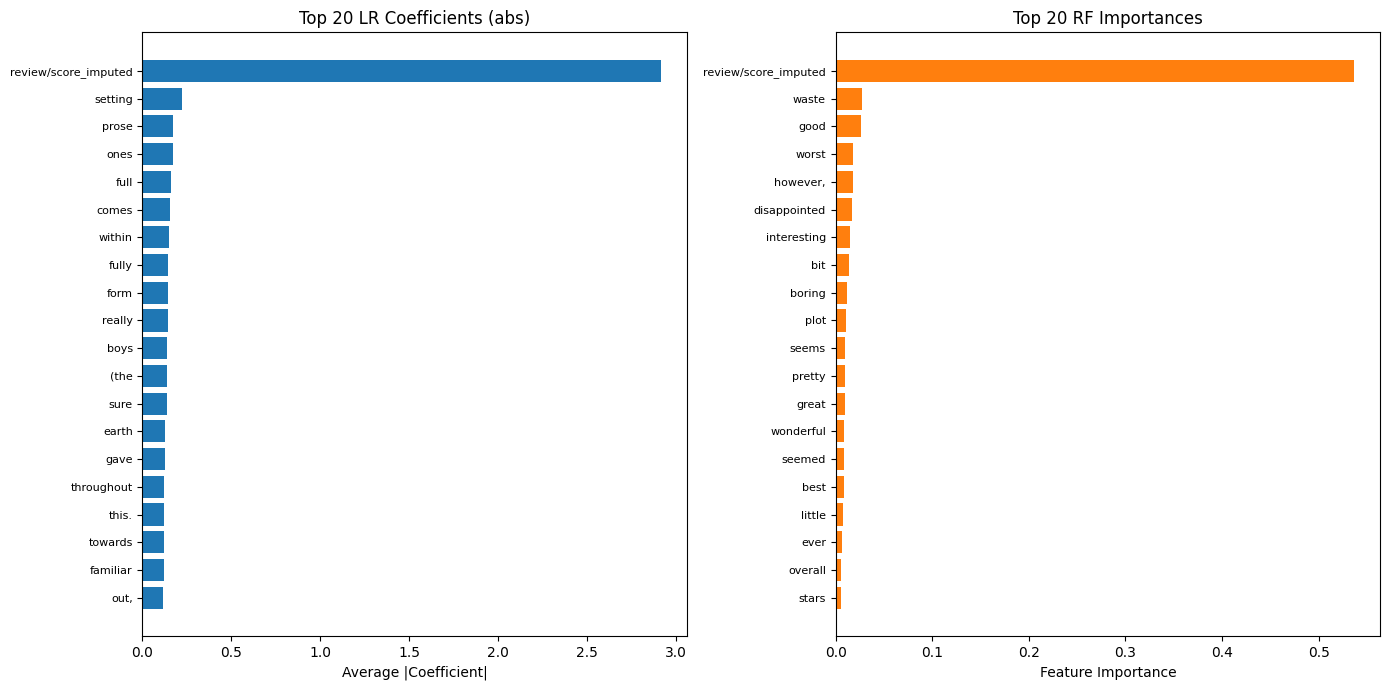

In [91]:
import numpy as np
import matplotlib.pyplot as plt
numeric_feats = ["Price_imputed", "ratingsCount_imputed", "review/score_imputed"]
vocab = cvModel.vocabulary           
feature_names = numeric_feats + vocab
assert len(feature_names) == len(rf_model.featureImportances.toArray()), (
    f"got {len(feature_names)} names but {rf_model.featureImportances.size} importances"
)
if hasattr(lr_model, "coefficientMatrix"):
    coef_mat  = np.array(lr_model.coefficientMatrix.toArray())      
    lr_scores = np.mean(np.abs(coef_mat), axis=0)
else:
    
    lr_scores = np.abs(np.array(lr_model.coefficients.toArray()))
rf_scores = np.array(rf_model.featureImportances.toArray())
K = 20
top20_lr = np.argsort(lr_scores)[::-1][:K]
top20_rf = np.argsort(rf_scores)[::-1][:K]
lr_feats = [feature_names[i] for i in top20_lr[::-1]]
lr_vals  = [lr_scores[i]        for i in top20_lr[::-1]]
rf_feats = [feature_names[i] for i in top20_rf[::-1]]
rf_vals  = [rf_scores[i]        for i in top20_rf[::-1]]
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=False)
axes[0].barh(lr_feats, lr_vals)
axes[0].set_title("Top 20 LR Coefficients (abs)")
axes[0].tick_params(axis="y", labelsize=8)
axes[0].set_xlabel("Average |Coefficient|")
axes[1].barh(rf_feats, rf_vals, color="C1")
axes[1].set_title("Top 20 RF Importances")
axes[1].tick_params(axis="y", labelsize=8)
axes[1].set_xlabel("Feature Importance")
plt.tight_layout()
plt.show()

### 3) Misclassification Pattern and Error Analysis

In [71]:
from pyspark.sql.functions import abs as ps_abs
misclassified = multinomial_predictions.filter(
    multinomial_predictions.prediction != multinomial_predictions["review/score_imputed"]
)
total_misclassified = misclassified.count()
print(f"🔎 Total misclassified samples: {total_misclassified}")
print("\n💬 Some general misclassified samples:")
misclassified.select(
    "Title", "review/score_imputed", "prediction", "review/summary", "review/text"
).show(5, truncate=False)
misclassified = misclassified.withColumn(
    "abs_error", ps_abs(misclassified["prediction"] - misclassified["review/score_imputed"])
)
print("\n🚨 Top 5 biggest misclassifications (any class):")
misclassified.orderBy("abs_error", ascending=False).select(
    "Title", "review/score_imputed", "prediction", "abs_error", "review/summary", "review/text"
).show(5, truncate=False)

🔎 Total misclassified samples: 8759

💬 Some general misclassified samples:


+----------------------------------------------------+--------------------+----------+--------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

+------------------------------------------------------------+--------------------+----------+---------+-----------------------------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

#### WordCloud of the Misclassified Reviews

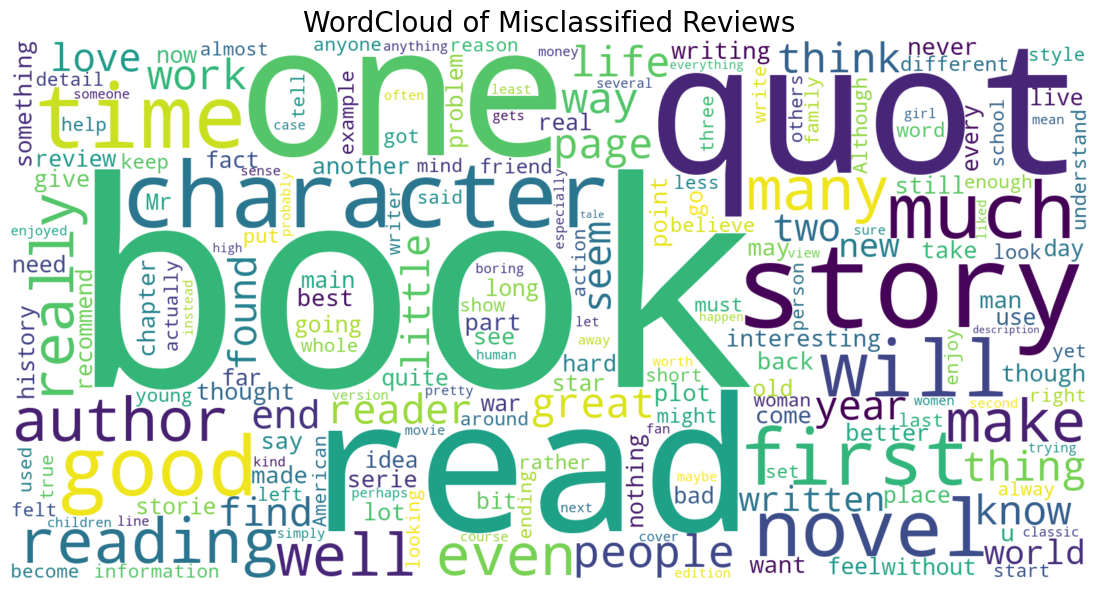

In [72]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
misclassified_texts = misclassified.select("review/text").rdd.flatMap(lambda x: x).collect()
all_text = " ".join(misclassified_texts)
wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    max_words=200,
    collocations=False  
).generate(all_text)
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud of Misclassified Reviews", fontsize=20)
plt.show()

### 4) Sentiment Distribution across Book Categories

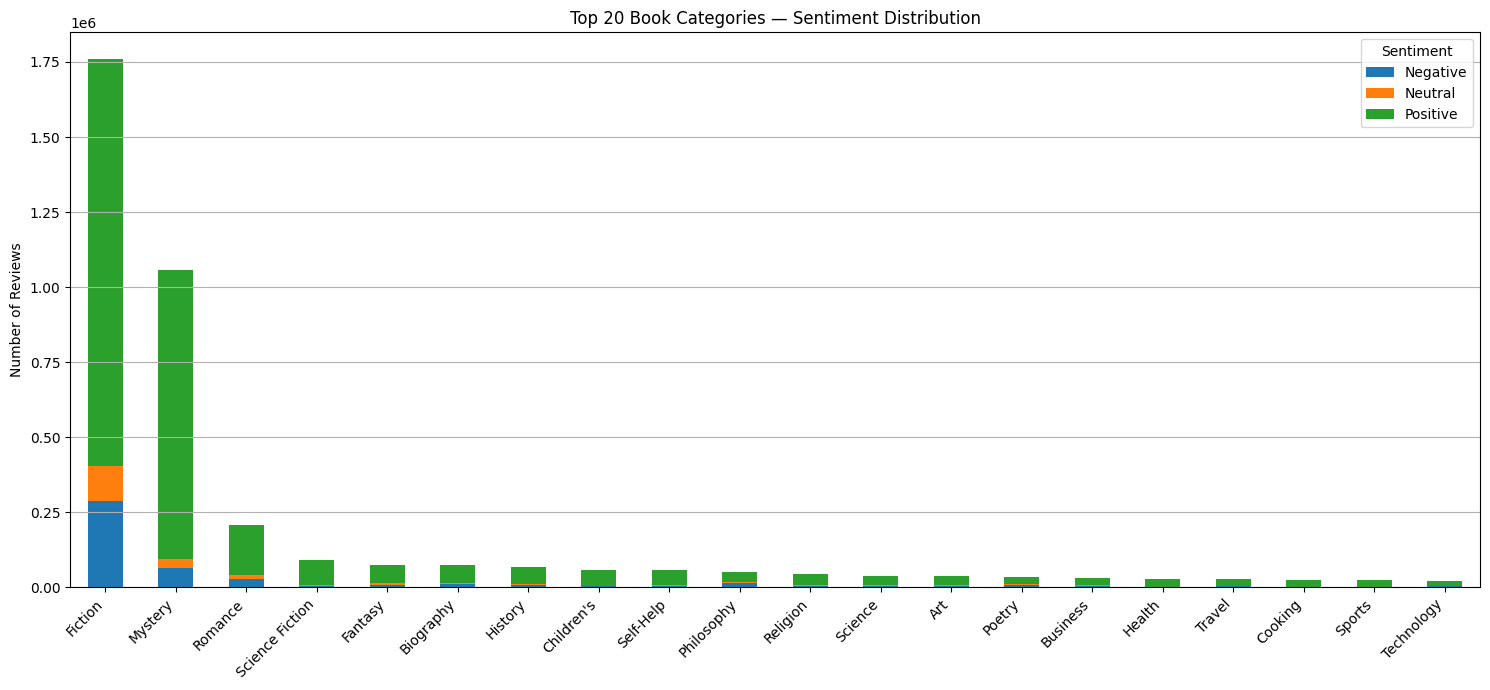

In [84]:
from pyspark.sql.functions import col, regexp_replace, split, explode, trim, when
import matplotlib.pyplot as plt
pred = multinomial_predictions.withColumnRenamed("categories", "orig_categories")
cats = processed_df.select(
    "Id",
    col("categories").alias("joined_categories")     
)
full = pred.join(cats, on="Id", how="left")
full2 = full.withColumn(
    "category_arr",
    split(
        regexp_replace(col("joined_categories"), r"[\[\]']", ""),  
        r",\s*"                                                   
    )
)
exploded0 = full2.withColumn("cat0", explode(col("category_arr")))
exploded = exploded0.withColumn("category", trim(col("cat0"))) \
                    .drop("cat0", "joined_categories", "category_arr")
sentimented = exploded.withColumn(
    "sentiment",
    when(col("prediction") >= 4.0, "Positive")
      .when(col("prediction") == 3.0, "Neutral")
      .otherwise("Negative")
)
counts = sentimented.groupBy("category", "sentiment").count()
pivoted = counts.groupBy("category") \
                .pivot("sentiment", ["Negative", "Neutral", "Positive"]) \
                .sum("count") \
                .fillna(0)
pdf = pivoted.toPandas()
pdf["Total"] = pdf[["Negative", "Neutral", "Positive"]].sum(axis=1)
pdf = pdf.sort_values("Total", ascending=False).drop(columns=["Total"])
top20 = pdf.head(20)
category_names = [
    "Fiction", "Mystery", "Romance", "Science Fiction", "Fantasy",
    "Biography", "History", "Children's", "Self-Help", "Philosophy",
    "Religion", "Science", "Art", "Poetry", "Business",
    "Health", "Travel", "Cooking", "Sports", "Technology",
]
mapping = dict(zip(top20.index, category_names))
top20_renamed = top20.rename(index=mapping)
ax = top20_renamed.plot(
    kind="bar",
    stacked=True,
    figsize=(15,7)
)
ax.set_ylabel("Number of Reviews")
ax.set_title("Top 20 Book Categories — Sentiment Distribution")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Sentiment")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

### 5) Temporal Analysis of Review Trends

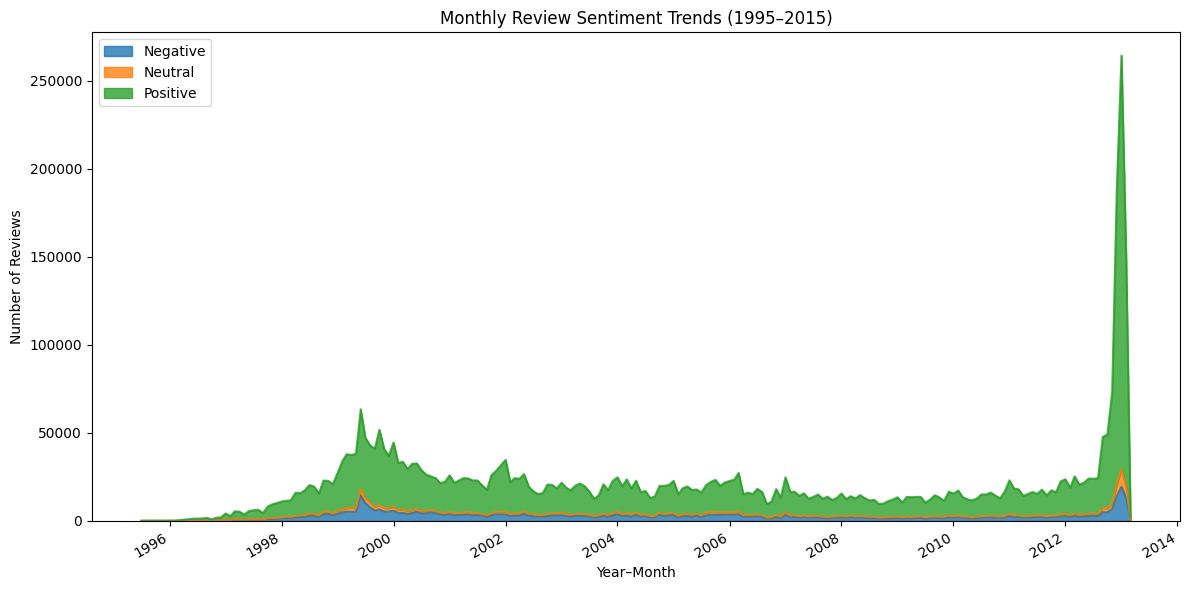

In [88]:
from pyspark.sql.functions import date_format, when, col
import pandas as pd
import matplotlib.pyplot as plt
time_df = processed_df.select(
    "Id",
    col("review/time").alias("orig_time")   
)
pred_time = multinomial_predictions.join(time_df, on="Id", how="left")
pred_time = pred_time.withColumn(
    "year_month",
    date_format(col("orig_time"), "yyyy-MM")
)
pred_time = pred_time.filter(
    (col("year_month") >= "1995-01") &
    (col("year_month") <= "2015-12")
)
pred_time = pred_time.withColumn(
    "sentiment",
    when(col("prediction") >= 4.0, "Positive")
     .when(col("prediction") == 3.0, "Neutral")
     .otherwise("Negative")
)
trend = pred_time.groupBy("year_month", "sentiment").count()
trend_pivot = (
    trend
    .groupBy("year_month")
    .pivot("sentiment", ["Negative","Neutral","Positive"])
    .sum("count")
    .fillna(0)
    .orderBy("year_month")
)
trend_pd = trend_pivot.toPandas()
trend_pd["year_month"] = pd.to_datetime(trend_pd["year_month"])
trend_pd = trend_pd.set_index("year_month").sort_index()
ax = trend_pd.plot.area(figsize=(12,6), alpha=0.8)
ax.set_xlabel("Year–Month")
ax.set_ylabel("Number of Reviews")
ax.set_title("Monthly Review Sentiment Trends (1995–2015)")
plt.tight_layout()
plt.show()

### Writing all the prediction results

In [93]:
from pyspark.ml import PipelineModel
from pyspark.sql import SparkSession
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
pipelineModel = PipelineModel(stages=[cvModel, idfModel, assembler, rf_model])
pipeline_dir   = "hdfs://localhost:9000/user/sathw/output/model_pipeline"
pipelineModel.write().overwrite().save(pipeline_dir)
print(f" PipelineModel saved to {pipeline_dir}")
preds = pipelineModel.transform(test_df)
preds_to_save = preds.select(
    "Id",
    "Title",
    "review/score_imputed",
    "prediction",
    "probability"
)
preds_dir = "hdfs://localhost:9000/user/sathw/output/predictions"
preds_to_save.write.mode("overwrite").parquet(preds_dir)
print(f"Predictions saved to {preds_dir}")
evaluator = MulticlassClassificationEvaluator(
    labelCol="review/score_imputed",
    predictionCol="prediction"
)
accuracy  = evaluator.setMetricName("accuracy").evaluate(preds)
precision = evaluator.setMetricName("weightedPrecision").evaluate(preds)
recall    = evaluator.setMetricName("weightedRecall").evaluate(preds)
f1_score  = evaluator.setMetricName("f1").evaluate(preds)
metrics = spark.createDataFrame(
    [(accuracy, precision, recall, f1_score)],
    ["accuracy", "precision", "recall", "f1_score"]
)
metrics_dir = "hdfs://localhost:9000/user/sathw/output/metrics"
metrics.write.mode("overwrite").json(metrics_dir)
print(f" Metrics saved to {metrics_dir}")

✅ PipelineModel saved to hdfs://localhost:9000/user/sathw/output/model_pipeline


25/04/27 04:38:19 WARN DAGScheduler: Broadcasting large task binary with size 6.3 MiB


✅ Predictions saved to hdfs://localhost:9000/user/sathw/output/predictions


25/04/27 04:38:26 WARN DAGScheduler: Broadcasting large task binary with size 6.1 MiB
25/04/27 04:38:33 WARN DAGScheduler: Broadcasting large task binary with size 6.1 MiB
25/04/27 04:38:40 WARN DAGScheduler: Broadcasting large task binary with size 6.1 MiB
25/04/27 04:38:50 WARN DAGScheduler: Broadcasting large task binary with size 6.1 MiB


✅ Metrics saved to hdfs://localhost:9000/user/sathw/output/metrics


25/04/27 05:59:27 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 3363393 ms exceeds timeout 800000 ms
25/04/27 05:59:27 WARN SparkContext: Killing executors is not supported by current scheduler.
25/04/27 06:48:58 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:80)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:642)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1223)
	at 